In [1]:
import weatherduck
import fiddle.graphviz
import fiddle as fdl

/Users/B280936/git-repos/anemoi/weatherduck/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


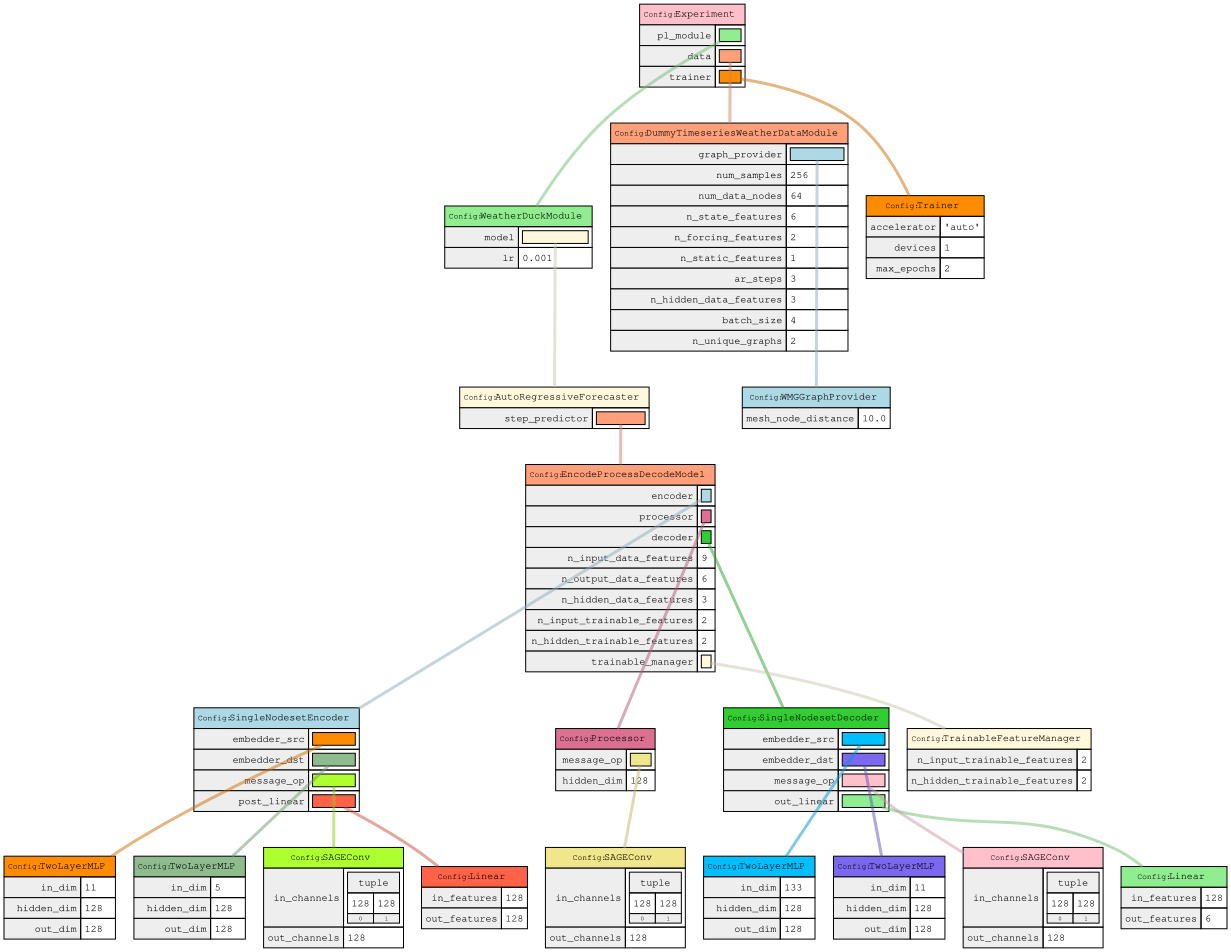

In [2]:
cfg = weatherduck.autoregressive_experiment_factory.as_buildable()
fiddle.graphviz.render(cfg)

In [3]:
cfg.pl_module.model.step_predictor.encoder

<Config[SingleNodesetEncoder(
  embedder_src=<Config[TwoLayerMLP(in_dim=11, hidden_dim=128, out_dim=128)]>,
  embedder_dst=<Config[TwoLayerMLP(in_dim=5, hidden_dim=128, out_dim=128)]>,
  message_op=<Config[SAGEConv(in_channels=(128, 128), out_channels=128)]>,
  post_linear=<Config[Linear(in_features=128, out_features=128)]>)]>

In [4]:
from fiddle.experimental.yaml_serialization import dump_yaml

In [ ]:
import torch
# overriding some config values
cfg.data.batch_size = 42
# replace post_linear with a torch.nn.Identity layer
cfg.pl_module.model.step_predictor.encoder.post_linear = torch.nn.Identity
exp = fdl.build(cfg)
print(exp)
# run the experiment with exp.run()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Experiment(pl_module=WeatherDuckModule(
  (model): AutoRegressiveForecaster(
    (step_predictor): EncodeProcessDecodeModel(
      (encoder): SingleNodesetEncoder(
        (embedder_src): TwoLayerMLP(
          (net): Sequential(
            (0): Linear(in_features=11, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=128, bias=True)
          )
        )
        (embedder_dst): TwoLayerMLP(
          (net): Sequential(
            (0): Linear(in_features=5, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=128, bias=True)
          )
        )
        (message_op): SAGEConv((128, 128), 128, aggr=mean)
        (activation): GELU(approximate='none')
      )
      (processor): Processor(
        (message_op): SAGEConv((128, 128), 128, aggr=mean)
        (mlp): Sequential(
          (0): GELU(approximate='none')
          (1): Linear(in_feat

/Users/B280936/git-repos/anemoi/weatherduck/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


## Outputting config to YAML (e.g. for mlflow logging)

In [6]:
print(dump_yaml(cfg))

RepresenterError: ('cannot represent an object', <class 'torch.nn.modules.linear.Identity'>)